In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

## Discrete fourier transform grid

Let's play around with this for a while

In [40]:
import os
import torch
from script.analysis.analysis_dft import Analysis
from script.model_dim_4_layer_3 import MinimalTransformer, vocab_size, test_loader


checkpoint_dir = '../checkpoints'
full_path = os.path.join(checkpoint_dir, 'dim_4_layer_3.pth')

checkpoint = torch.load(full_path)
checkpoint = checkpoint['model_state_dict']


model = MinimalTransformer(vocab_size=vocab_size)
analysis = Analysis(model=model, skeleton=checkpoint, vocab_size=vocab_size, data=test_loader) 


print(f"Diagonal Sperectal Mass {analysis.diagonal_sperectal_mass()}")
"checked"



correct: 520/5000 = 10.4%
unique (a,b) pairs seen: 60
Diagonal Sperectal Mass 0.07956695556640625


'checked'

Let's try to visuzlize that heatmap in `nxn` lattice

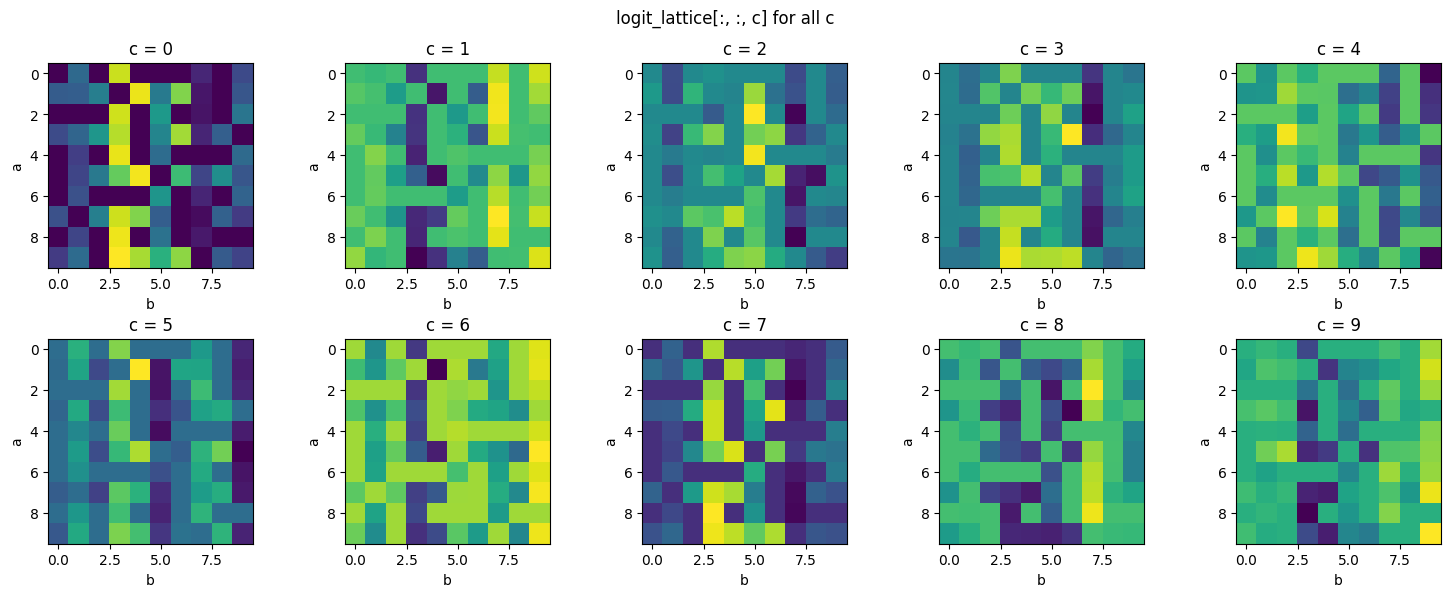

In [41]:
analysis.heat_map()

### Different approach of generating data

In [42]:
from torch.utils.data import random_split
from script.model_dim_4_layer_3 import FibonacciModDatasetSmallShample

generated_ds = FibonacciModDatasetSmallShample(num_samples=25000, mod=vocab_size, seq_len=20)

train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size])
print(test_ds[0])

(tensor([1, 9, 0, 9, 9, 8, 7, 5, 2, 7, 9, 6, 5, 1, 6, 7, 3, 0, 3, 3]), tensor([9, 0, 9, 9, 8, 7, 5, 2, 7, 9, 6, 5, 1, 6, 7, 3, 0, 3, 3, 6]))


### Let's see the same analysis in the model trained with `Alternate dataset`

In [43]:
import os
import torch
from script.analysis.analysis_dft import Analysis
from script.model_dim_4_layer_3 import MinimalTransformer, vocab_size, test_loader


checkpoint_dir = '../checkpoints'
full_path = os.path.join(checkpoint_dir, 'dim_4_layer_3_alterset.pth')

checkpoint = torch.load(full_path)
checkpoint = checkpoint['model_state_dict']


model = MinimalTransformer(vocab_size=vocab_size)
analysis = Analysis(model=model, skeleton=checkpoint, vocab_size=vocab_size, data=test_loader) 


print(f"Diagonal Sperectal Mass {analysis.diagonal_sperectal_mass()}")
"Checked"

correct: 644/5000 = 12.9%
unique (a,b) pairs seen: 60
Diagonal Sperectal Mass 0.07946806401014328


'Checked'

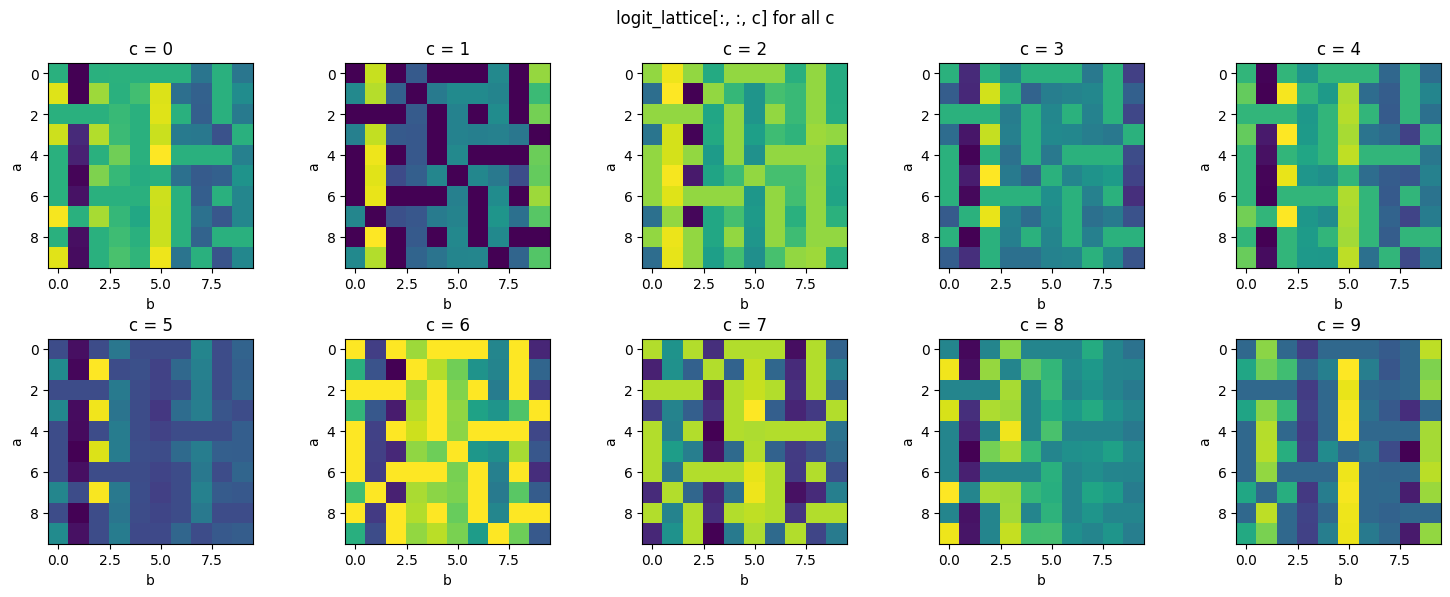

In [44]:
analysis.heat_map()